# IMPORT

In [1]:
pip install lingam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 8.2 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659681 sha256=84a07ca9e8ae6466cf15a4e8e6727cd21e66325287092c86b4efcf2ce025e735
  Stored in directory: /root/.cache/pip/wheels/53/ec/0d/0b294c02d8c4e9e80afea58839f2c1b4706770594bc99ec045
Successfully built semopy
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import style
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder
import lingam
from lingam import DirectLiNGAM
from lingam.utils import make_dot


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# DATASET

In [4]:
#Загружаем датасет
#df = pd.read_csv('./Data/wells.csv')
df = pd.read_csv('/content/drive/MyDrive/wells.csv')

df["START_DATE_FACT"] = pd.to_datetime(df["START_DATE_FACT"])
df["END_DATE_FACT"] = pd.to_datetime(df["END_DATE_FACT"])
df["MEASURED_IN_DATE"] = pd.to_datetime(df["MEASURED_IN_DATE"])
df['LIQ_RATE'] = pd.to_numeric(df['LIQ_RATE'])
df['DATE_DIFFERENCE_START_END'] = df['END_DATE_FACT'] - df['START_DATE_FACT']
df['DATE_DIFFERENCE_START_MEASURED'] = df['MEASURED_IN_DATE'] - df['START_DATE_FACT']
df['DATE_DIFFERENCE_END_MEASURED'] = df['MEASURED_IN_DATE'] - df['END_DATE_FACT']
display(df.head())
display(df.info())

,WELL_NAME,COORD_X,COORD_Y,X2,Y2,CHARWORK_unique,GEOTECH_ACTION,START_DATE_FACT,END_DATE_FACT,MEASURED_IN_DATE,...,MEASURED_IN,LIQ_RATE,WATER_CUT,P_ZAB,INTAKE,WELLHEAD_PRESSURE,IS_WORKING,DATE_DIFFERENCE_START_END,DATE_DIFFERENCE_START_MEASURED,DATE_DIFFERENCE_END_MEASURED
0,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,11611.72,3450.28,11769.95,2921.2,НЕФ,Из бурения,2018-09-08,2018-09-10,2018-09-15,...,2018-09-15 11:40:00,550.0,20.0,113.80,0.0,NaN,True,2 days,7 days,5 days
1,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,11611.72,3450.28,11769.95,2921.2,НЕФ,Из бурения,2018-09-08,2018-09-10,2018-09-16,...,2018-09-16 00:00:00,550.0,20.0,113.80,0.0,NaN,True,2 days,8 days,6 days
2,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,11611.72,3450.28,11769.95,2921.2,НЕФ,Из бурения,2018-09-08,2018-09-10,2018-09-17,...,2018-09-17 00:00:00,536.0,20.0,107.10,0.0,NaN,True,2 days,9 days,7 days
3,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,11611.72,3450.28,11769.95,2921.2,НЕФ,Из бурения,2018-09-08,2018-09-10,2018-09-18,...,2018-09-18 00:00:00,539.0,10.0,106.58,0.0,NaN,True,2 days,10 days,8 days
4,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,11611.72,3450.28,11769.95,2921.2,НЕФ,Из бурения,2018-09-08,2018-09-10,2018-09-19,...,2018-09-19 00:00:00,539.0,10.0,103.17,0.0,NaN,True,2 days,11 days,9 days


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311156 entries, 0 to 311155
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype          
---  ------                          --------------   -----          
 0   WELL_NAME                       311156 non-null  object         
 1   COORD_X                         311156 non-null  float64        
 2   COORD_Y                         311156 non-null  float64        
 3   X2                              311156 non-null  float64        
 4   Y2                              311156 non-null  float64        
 5   CHARWORK_unique                 311156 non-null  object         
 6   GEOTECH_ACTION                  311156 non-null  object         
 7   START_DATE_FACT                 311156 non-null  datetime64[ns] 
 8   END_DATE_FACT                   311156 non-null  datetime64[ns] 
 9   MEASURED_IN_DATE                311156 non-null  datetime64[ns] 
 10  KCHARWORK                       311156 non-n

None

In [5]:
#Выделяем в датасете необходимые параметры
params = df[["WELL_NAME", "CHARWORK", "GEOTECH_ACTION", "WATER_CUT", "LIQ_RATE", "P_ZAB", "INTAKE", "WELLHEAD_PRESSURE", "MEASURED_IN_DATE", 'DATE_DIFFERENCE_START_END', "IS_WORKING"]]
params.head(-10)

,WELL_NAME,CHARWORK,GEOTECH_ACTION,WATER_CUT,LIQ_RATE,P_ZAB,INTAKE,WELLHEAD_PRESSURE,MEASURED_IN_DATE,DATE_DIFFERENCE_START_END,IS_WORKING
0,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,НЕФ,Из бурения,20.0,550.0,113.80,0.0,NaN,2018-09-15,2 days,True
1,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,НЕФ,Из бурения,20.0,550.0,113.80,0.0,NaN,2018-09-16,2 days,True
2,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,НЕФ,Из бурения,20.0,536.0,107.10,0.0,NaN,2018-09-17,2 days,True
3,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,НЕФ,Из бурения,10.0,539.0,106.58,0.0,NaN,2018-09-18,2 days,True
4,769384f0a6fe5cba75fc68a9e52395eb9b69fa8dab849e...,НЕФ,Из бурения,10.0,539.0,103.17,0.0,NaN,2018-09-19,2 days,True
...,...,...,...,...,...,...,...,...,...,...,...
311141,38d16984b35375661ce394b7832698d12bc0e91606aeff...,НЕФ,Из бурения,11.0,144.0,62.59,0.0,NaN,2022-05-11,3 days,True
311142,38d16984b35375661ce394b7832698d12bc0e91606aeff...,НЕФ,Из бурения,11.0,144.0,56.58,0.0,NaN,2022-05-12,3 days,True
311143,38d16984b35375661ce394b7832698d12bc0e91606aeff...,НЕФ,Из бурения,10.0,144.0,56.56,0.0,NaN,2022-05-13,3 days,True
311144,38d16984b35375661ce394b7832698d12bc0e91606aeff...,НЕФ,Из бурения,10.0,144.0,56.06,0.0,NaN,2022-05-14,3 days,True


In [14]:
df_encoded = params.copy()

# Функция кодирования с сохранением NaN
def encode_with_nan(df, column):
    le = LabelEncoder()
    mask = df[column].notna()
    df.loc[mask, column] = le.fit_transform(df.loc[mask, column])
    return le

le_well_name = encode_with_nan(df_encoded, 'WELL_NAME')
#le_charwork = encode_with_nan(df_encoded, 'CHARWORK')
#le_geoteck_action = encode_with_nan(df_encoded, 'GEOTECH_ACTION')
#le_work = encode_with_nan(df_encoded, 'IS_WORKING')
#le_time = encode_with_nan(df_encoded, 'DATE_DIFFERENCE_START_END')

display(df_encoded.info())
display(df_encoded.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311156 entries, 0 to 311155
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype          
---  ------                     --------------   -----          
 0   WELL_NAME                  311156 non-null  object         
 1   CHARWORK                   311156 non-null  object         
 2   GEOTECH_ACTION             311156 non-null  object         
 3   WATER_CUT                  311156 non-null  float64        
 4   LIQ_RATE                   311156 non-null  float64        
 5   P_ZAB                      298382 non-null  float64        
 6   INTAKE                     311156 non-null  float64        
 7   WELLHEAD_PRESSURE          107777 non-null  float64        
 8   MEASURED_IN_DATE           311156 non-null  datetime64[ns] 
 9   DATE_DIFFERENCE_START_END  311156 non-null  timedelta64[ns]
 10  IS_WORKING                 311156 non-null  bool           
dtypes: bool(1), datetime64[ns](1), float64(

None

,WELL_NAME,CHARWORK,GEOTECH_ACTION,WATER_CUT,LIQ_RATE,P_ZAB,INTAKE,WELLHEAD_PRESSURE,MEASURED_IN_DATE,DATE_DIFFERENCE_START_END,IS_WORKING
0,127,НЕФ,Из бурения,20.0,550.0,113.80,0.0,NaN,2018-09-15,2 days,True
1,127,НЕФ,Из бурения,20.0,550.0,113.80,0.0,NaN,2018-09-16,2 days,True
2,127,НЕФ,Из бурения,20.0,536.0,107.10,0.0,NaN,2018-09-17,2 days,True
3,127,НЕФ,Из бурения,10.0,539.0,106.58,0.0,NaN,2018-09-18,2 days,True
4,127,НЕФ,Из бурения,10.0,539.0,103.17,0.0,NaN,2018-09-19,2 days,True


In [15]:
print(df_encoded['GEOTECH_ACTION'].unique())
print(df_encoded['WELL_NAME'].unique())
print(df_encoded['CHARWORK'].unique())
print(df_encoded['INTAKE'].unique())

['Из бурения' 'ИДН' 'ОПЗ' 'Перевод в ППД' 'Из БД' 'КРС' 'РИР'
 'Реконструкция' 'Из др.фонд']
[127 99 43 114 79 248 244 155 147 118 164 110 157 221 174 232 177 171 136
 224 217 78 206 254 218 3 261 49 116 53 216 167 126 131 192 41 223 14 38
 241 145 183 90 71 195 226 175 133 210 75 39 154 81 72 243 143 240 215 200
 259 172 166 11 231 201 139 134 237 153 152 89 197 205 149 107 163 112 211
 33 258 245 230 22 31 102 55 96 203 176 193 186 189 207 0 23 159 4 204 52
 213 140 212 247 113 135 57 249 32 45 132 10 161 162 87 199 40 252 202 106
 225 178 92 25 235 7 97 69 227 44 103 246 68 184 219 73 144 36 256 42 56
 93 15 98 169 109 91 151 173 198 12 63 19 54 76 187 51 150 253 37 194 214
 8 111 34 168 138 108 142 255 236 88 222 180 160 121 263 137 229 64 94 20
 82 47 250 179 101 122 66 48 128 13 257 196 1 165 242 74 251 28 228 16 120
 146 80 141 115 5 58 234 130 67 84 83 125 170 95 6 260 148 60 119 85 182
 188 29 123 233 220 209 30 104 46 100 2 17 124 50 265 129 35 190 262 77
 158 26 181 21 191 1

In [16]:

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311156 entries, 0 to 311155
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype          
---  ------                     --------------   -----          
 0   WELL_NAME                  311156 non-null  object         
 1   CHARWORK                   311156 non-null  object         
 2   GEOTECH_ACTION             311156 non-null  object         
 3   WATER_CUT                  311156 non-null  float64        
 4   LIQ_RATE                   311156 non-null  float64        
 5   P_ZAB                      298382 non-null  float64        
 6   INTAKE                     311156 non-null  float64        
 7   WELLHEAD_PRESSURE          107777 non-null  float64        
 8   MEASURED_IN_DATE           311156 non-null  datetime64[ns] 
 9   DATE_DIFFERENCE_START_END  311156 non-null  timedelta64[ns]
 10  IS_WORKING                 311156 non-null  bool           
dtypes: bool(1), datetime64[ns](1), float64(

In [17]:
df_encoded['LIQ_RATE']

,LIQ_RATE
0,550.0
1,550.0
2,536.0
3,539.0
4,539.0
...,...
311151,144.0
311152,144.0
311153,144.0
311154,144.0


# Analitycs

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


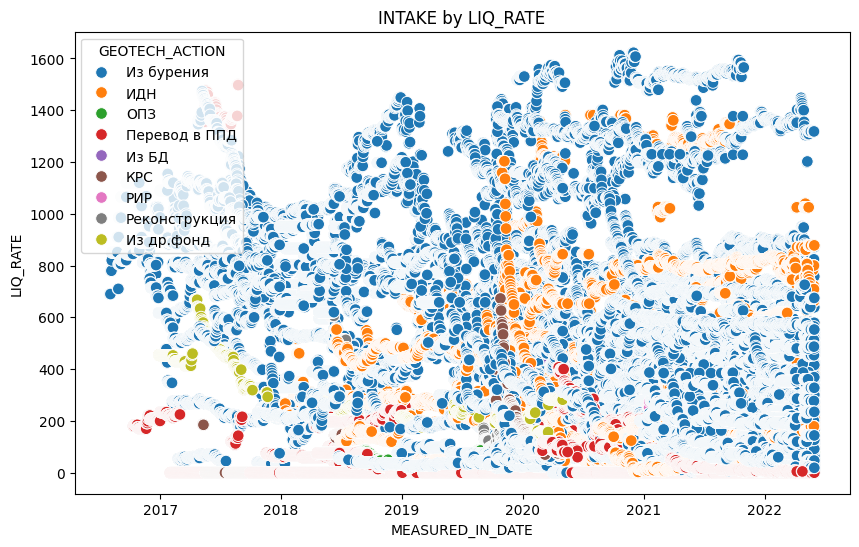

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="MEASURED_IN_DATE", y="LIQ_RATE", hue="GEOTECH_ACTION", data=df_encoded, s=70).set_title('INTAKE by LIQ_RATE')
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


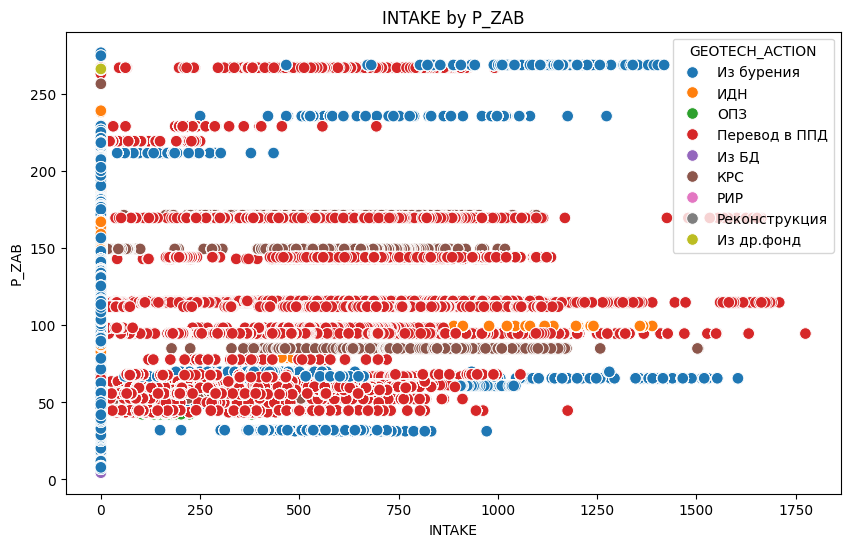

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="INTAKE", y="P_ZAB", hue="GEOTECH_ACTION", data=df_encoded, s=70).set_title('INTAKE by P_ZAB')
plt.show()

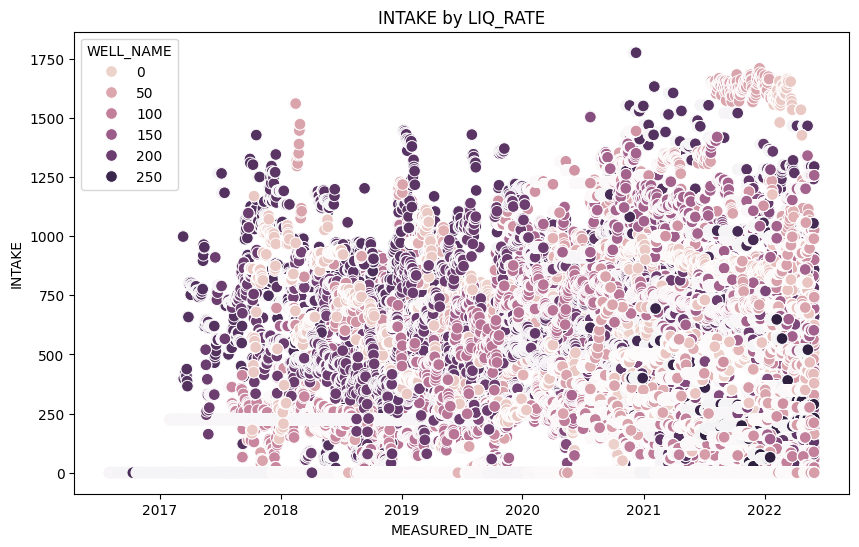

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="MEASURED_IN_DATE", y="INTAKE", hue="WELL_NAME", data=df_encoded, s=70).set_title('INTAKE by LIQ_RATE')
plt.show()

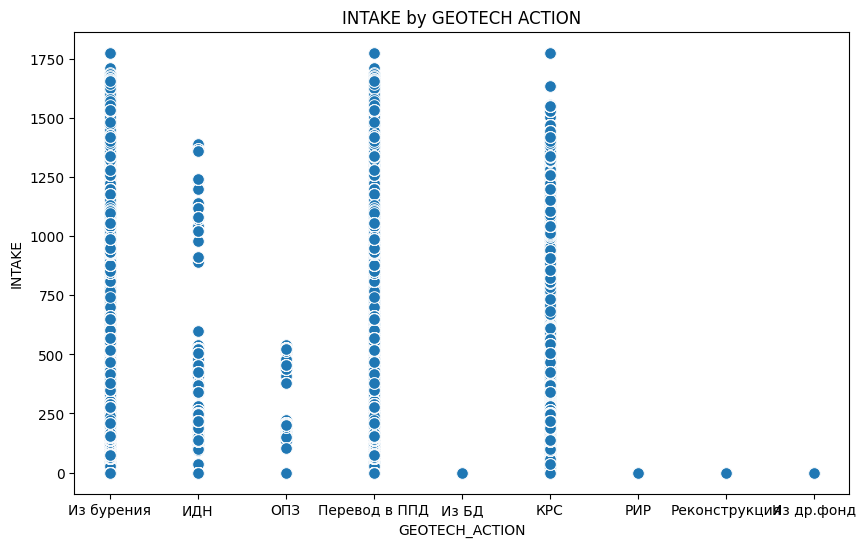

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(y="INTAKE", x="GEOTECH_ACTION", data=df_encoded, s=70).set_title('INTAKE by GEOTECH ACTION')
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


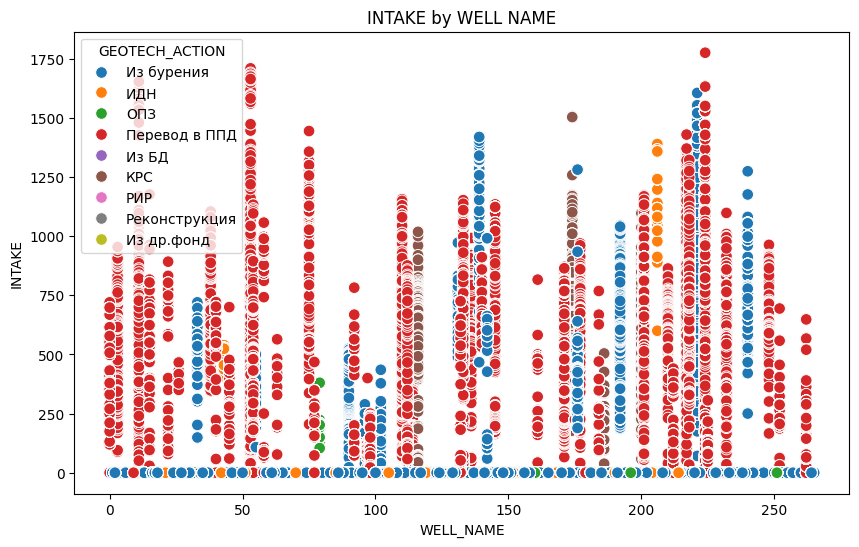

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="WELL_NAME", y="INTAKE", hue="GEOTECH_ACTION", data=df_encoded, s=70).set_title('INTAKE by WELL NAME')
plt.show()

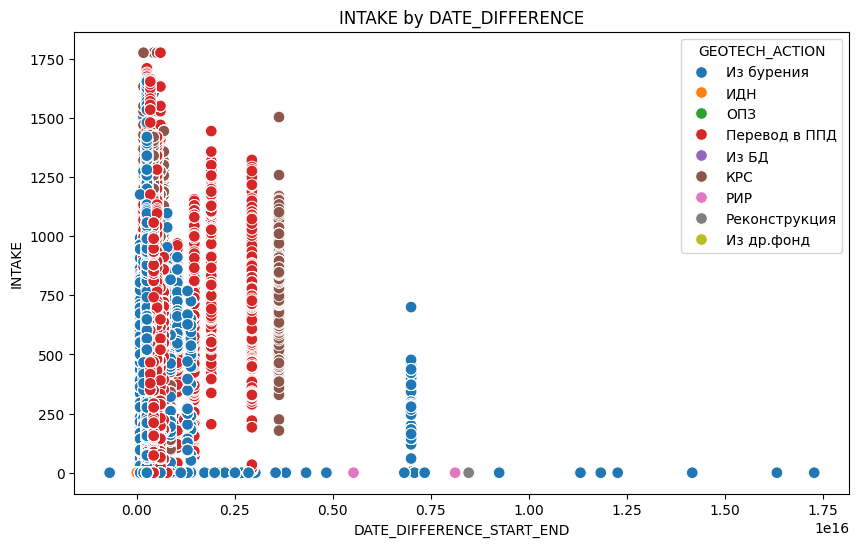

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="DATE_DIFFERENCE_START_END", y="INTAKE", hue="GEOTECH_ACTION", data=df_encoded, s=70).set_title('INTAKE by DATE_DIFFERENCE')
plt.show()

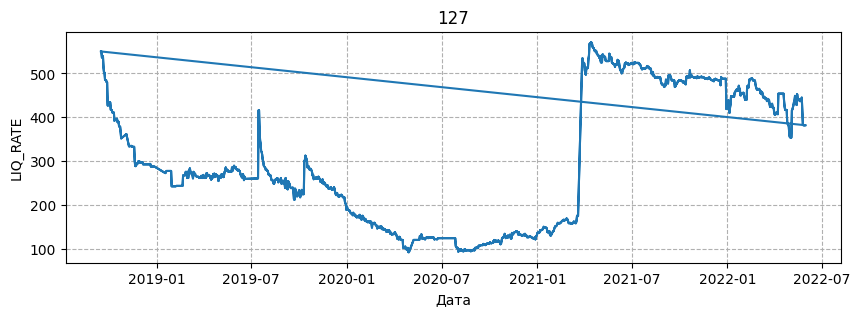

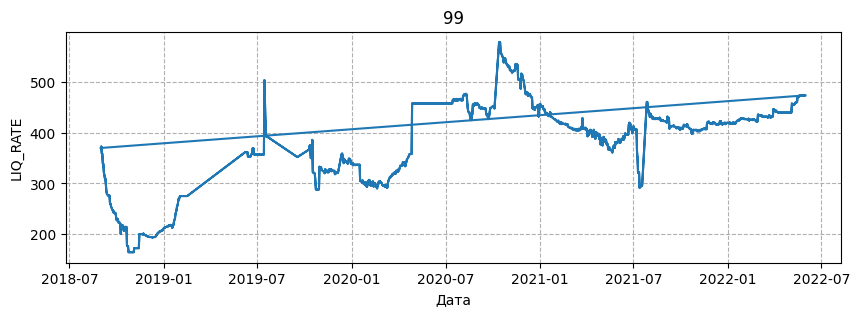

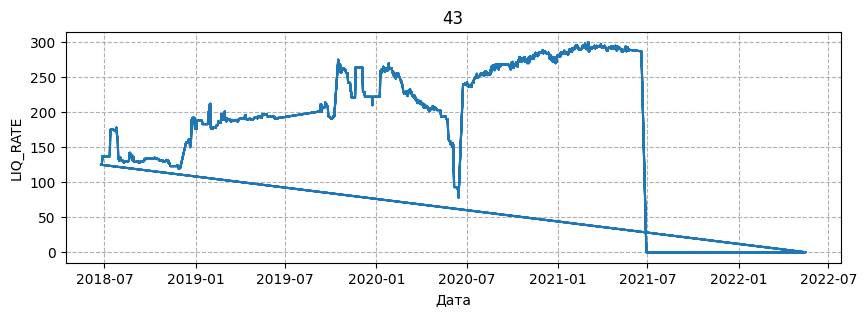

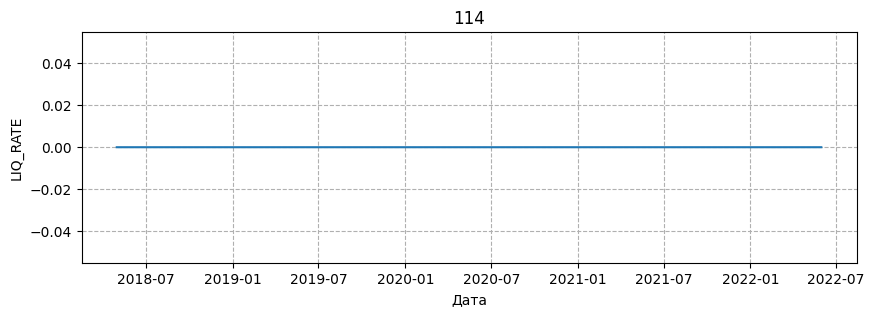

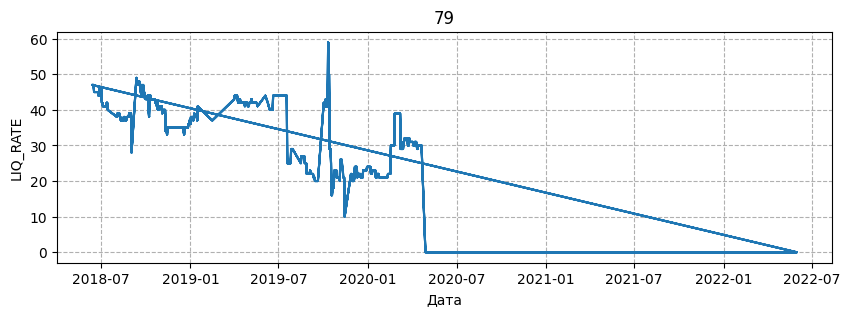

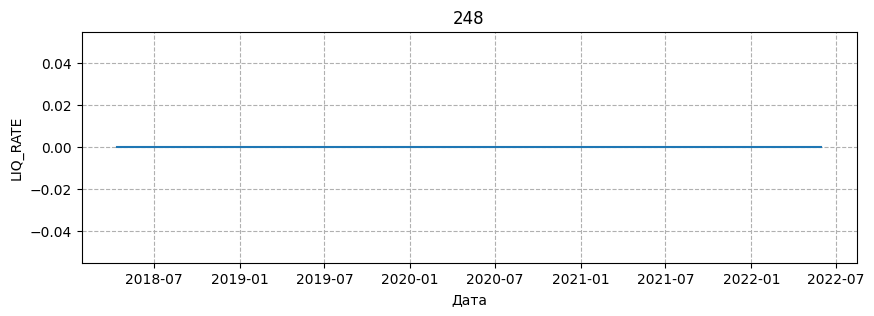

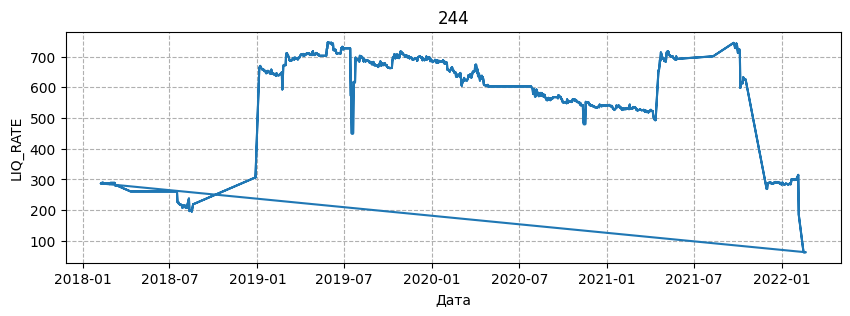

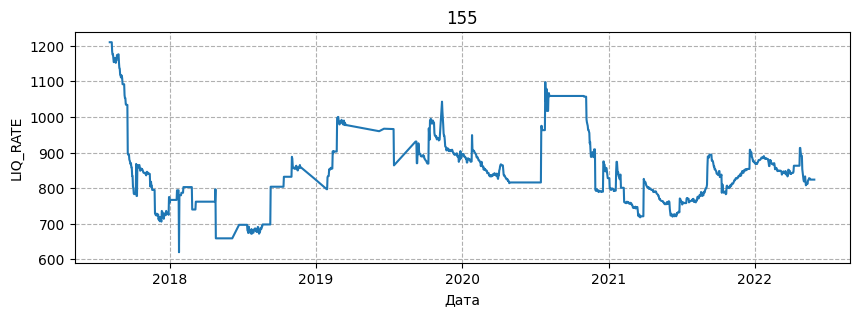

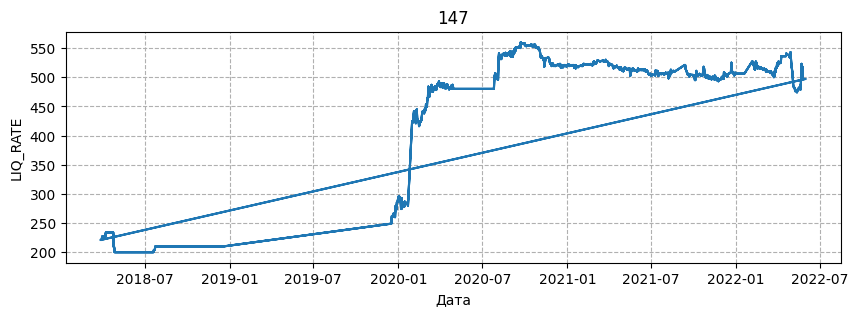

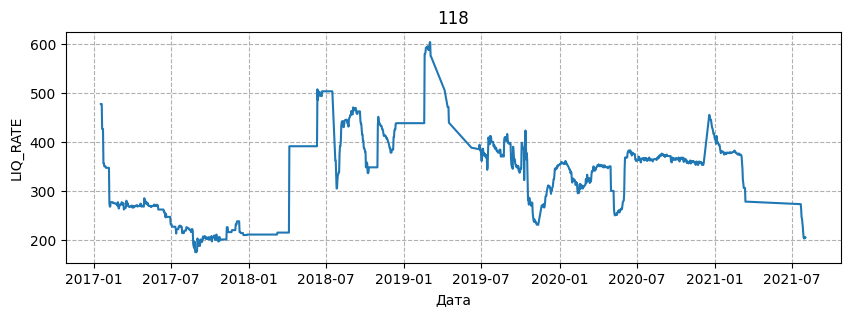

In [23]:
# Коэффициент ликвидности скважин

param = "LIQ_RATE"

for well in df_encoded['WELL_NAME'].unique()[:10]:
    tmp = df_encoded[df_encoded['WELL_NAME'] == well]
    plt.figure(figsize=(10, 3))

    plt.plot(tmp["MEASURED_IN_DATE"], tmp[param])
    plt.grid(ls="--")
    plt.title(well)
    plt.xlabel("Дата")
    plt.ylabel(param)

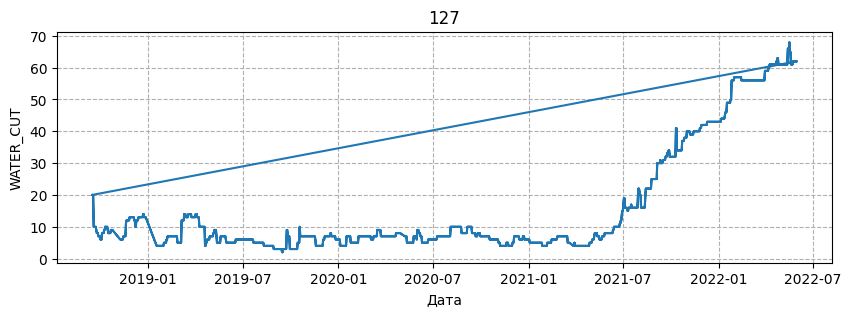

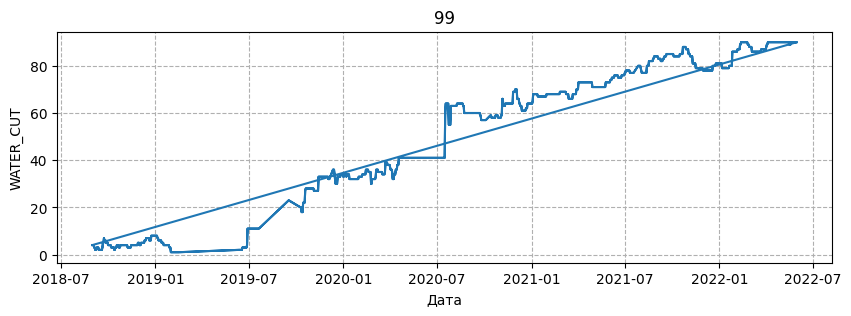

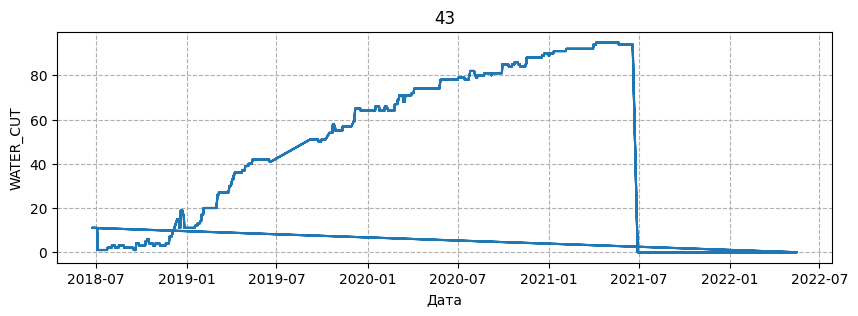

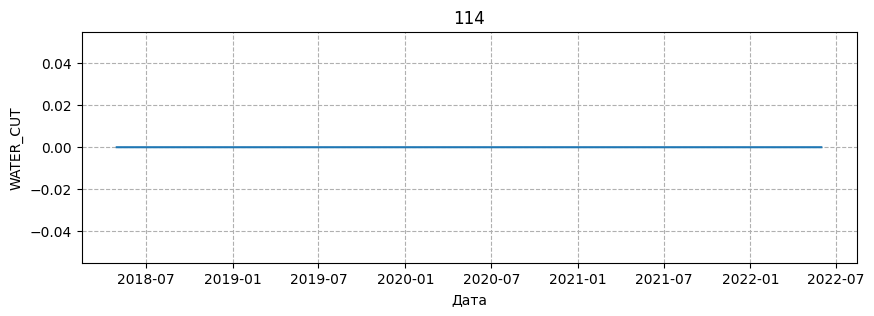

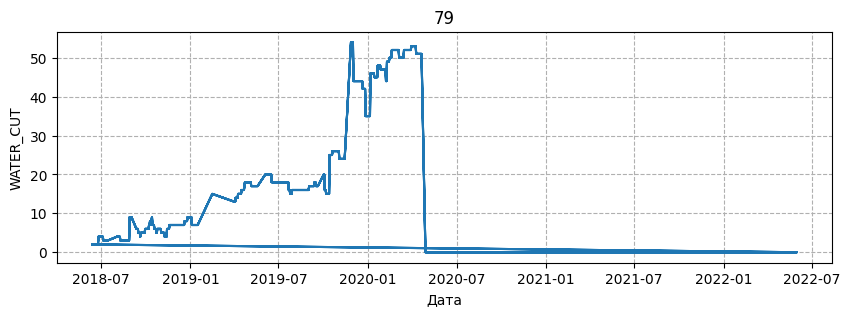

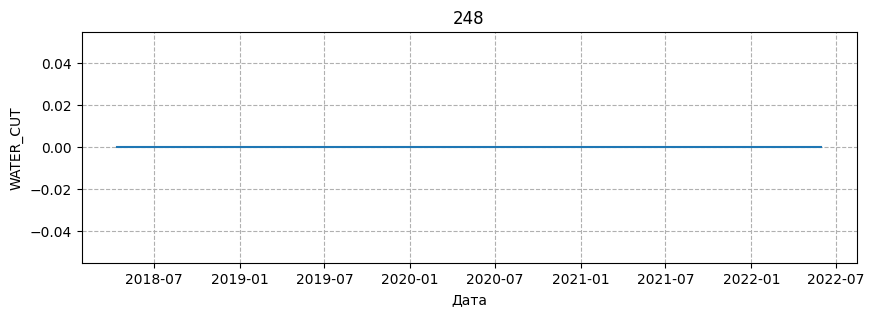

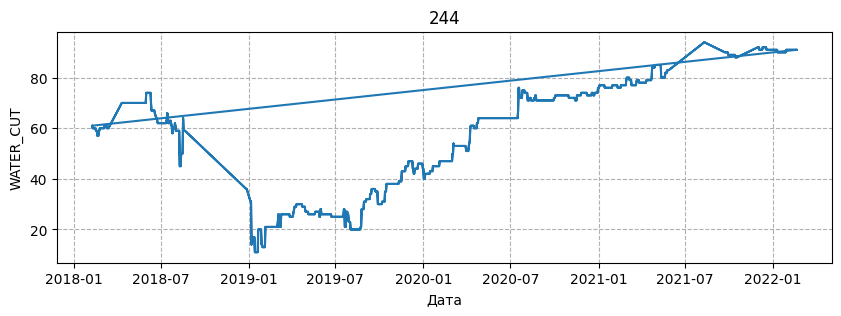

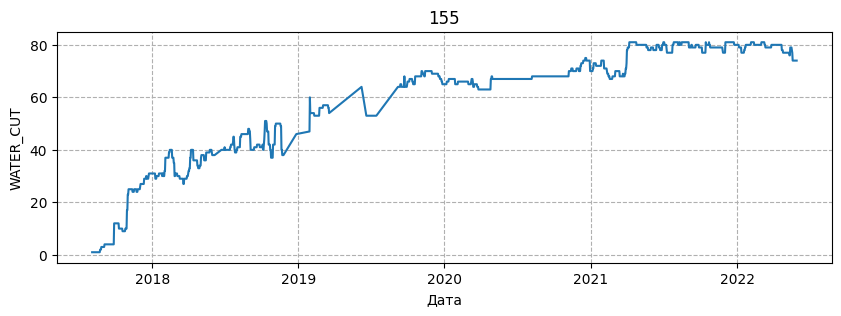

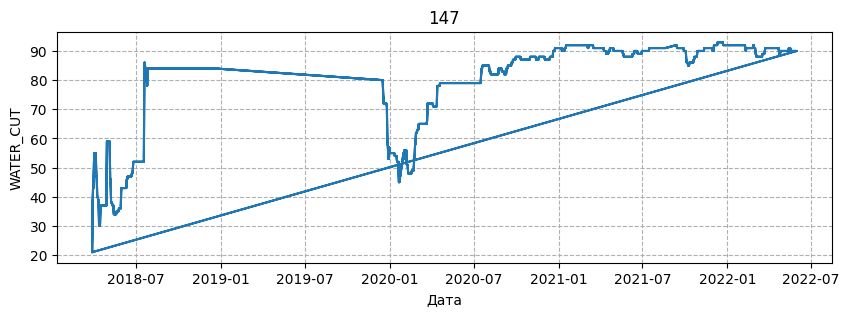

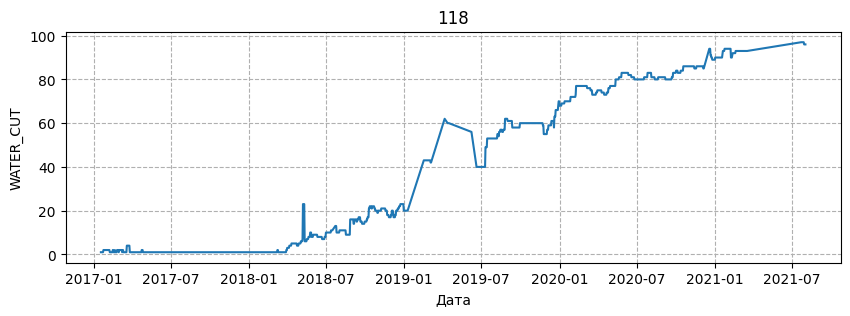

In [24]:
# Количество заборов воды

param = "WATER_CUT"

for well in df_encoded['WELL_NAME'].unique()[:10]:
    tmp = df_encoded[df_encoded['WELL_NAME'] == well]
    plt.figure(figsize=(10, 3))

    plt.plot(tmp["MEASURED_IN_DATE"], tmp[param])
    plt.grid(ls="--")
    plt.title(well)
    plt.xlabel("Дата")
    plt.ylabel(param)

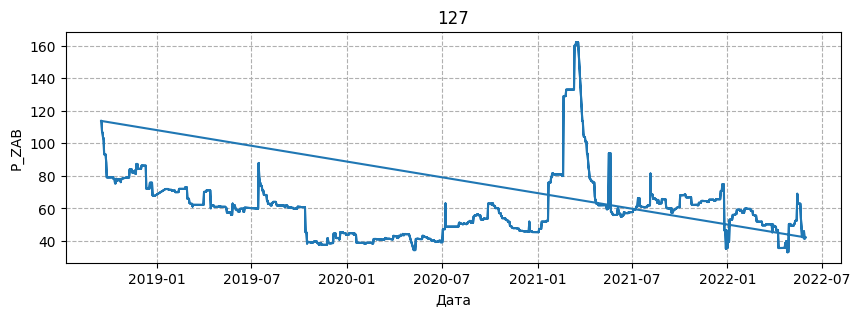

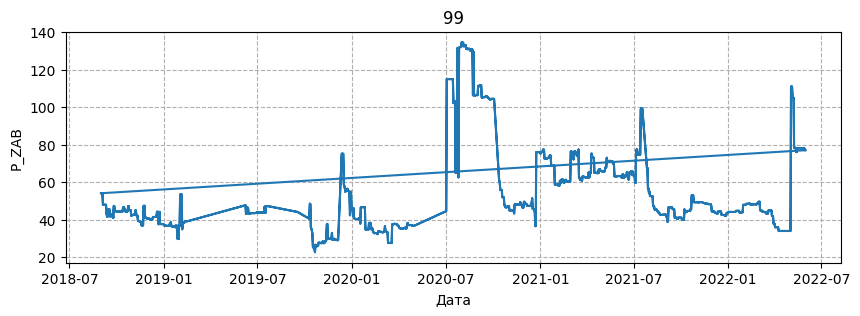

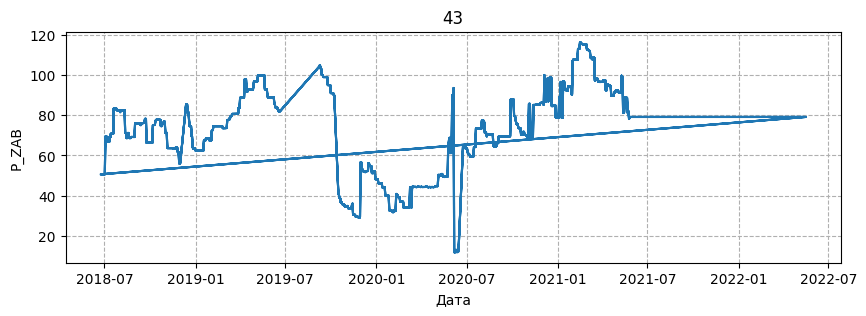

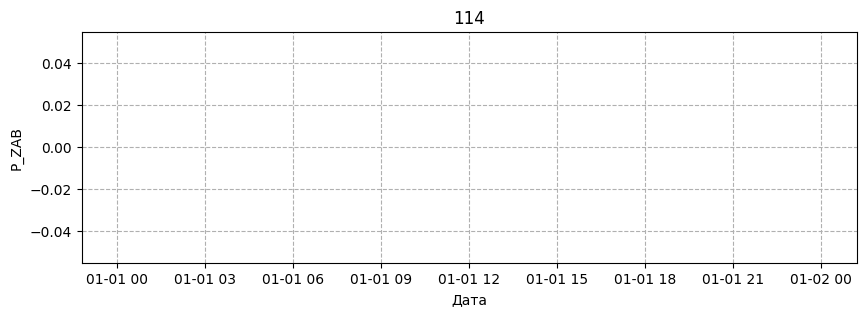

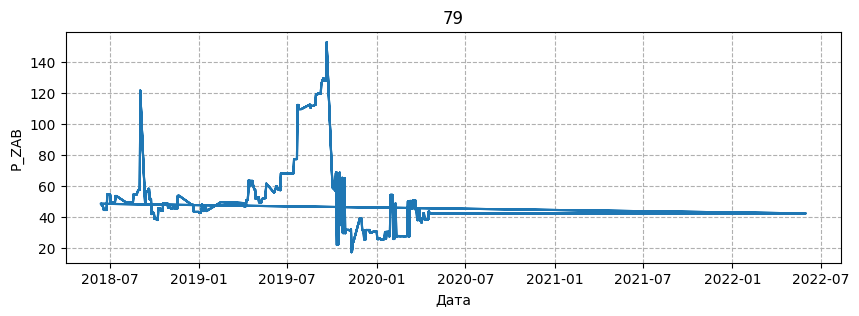

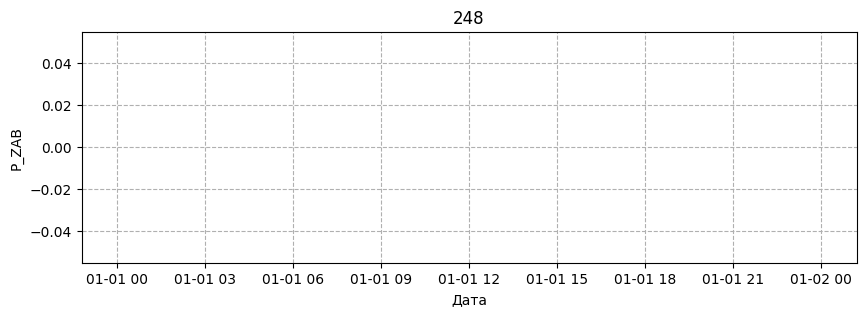

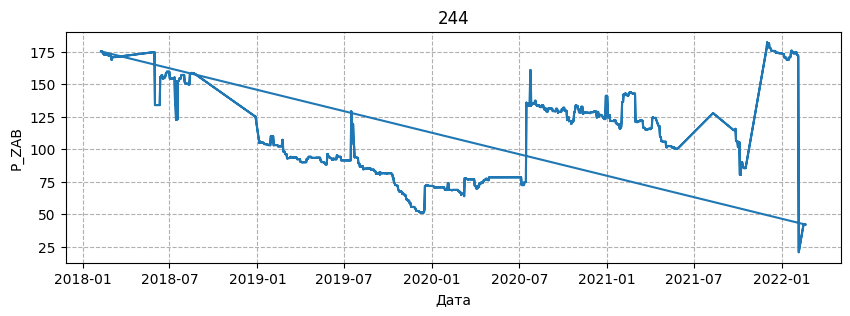

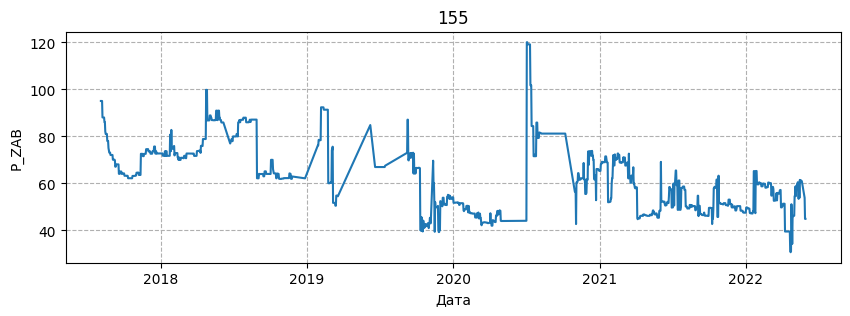

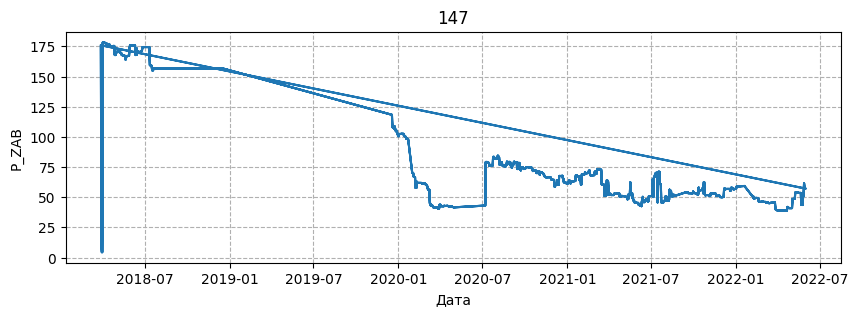

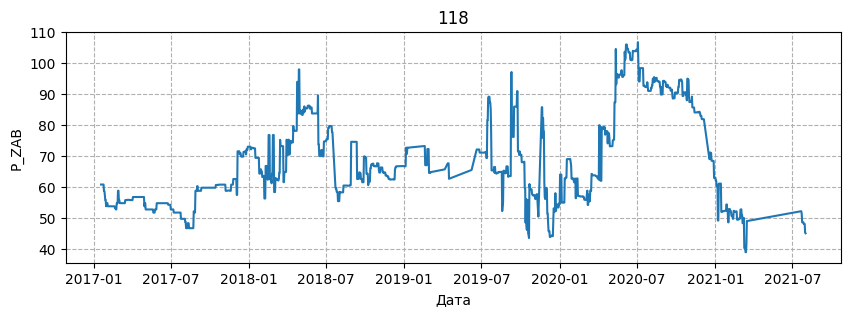

In [25]:
# Коэффициент ликвидности скважин

param = "P_ZAB"

for well in df_encoded['WELL_NAME'].unique()[:10]:
    tmp = df_encoded[df_encoded['WELL_NAME'] == well]
    plt.figure(figsize=(10, 3))

    plt.plot(tmp["MEASURED_IN_DATE"], tmp[param])
    plt.grid(ls="--")
    plt.title(well)
    plt.xlabel("Дата")
    plt.ylabel(param)

In [37]:
le_charwork = encode_with_nan(df_encoded, 'CHARWORK')
le_geoteck_action = encode_with_nan(df_encoded, 'GEOTECH_ACTION')
le_work = encode_with_nan(df_encoded, 'IS_WORKING')
#le_time = encode_with_nan(df_encoded, 'DATE_DIFFERENCE_START_END')

<ipython-input-14-a71512bf3687>:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[mask, column] = le.fit_transform(df.loc[mask, column])


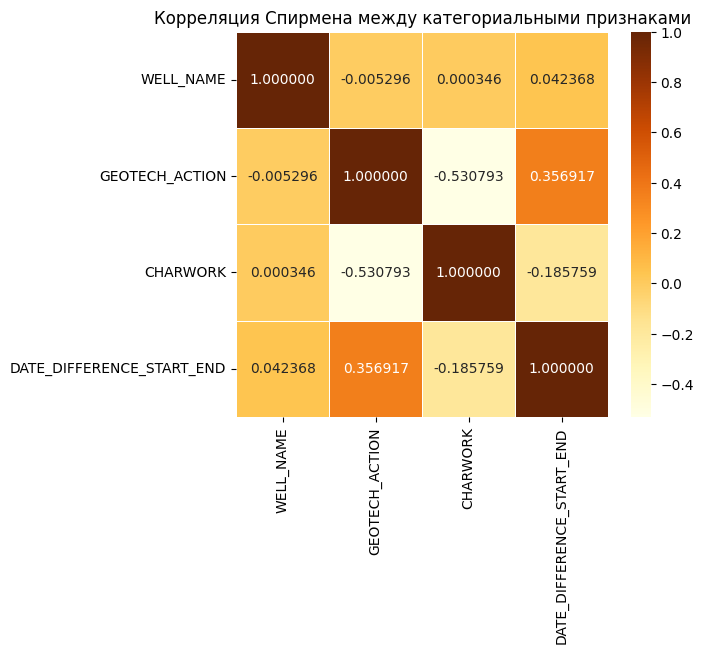

In [39]:
# Рассчитаем корреляцию Спирмена для категориальных признаков
spearman_corr = df_encoded[['WELL_NAME', 'GEOTECH_ACTION', 'CHARWORK', 'DATE_DIFFERENCE_START_END']].corr(method='spearman')

# Построим heatmap для корреляции Спирмена
plt.figure(figsize=(6, 5))
sns.heatmap(spearman_corr, annot=True, cmap='YlOrBr', fmt='.6f', linewidths=0.5)
plt.title('Корреляция Спирмена между категориальными признаками')
plt.show()

In [46]:
#Энкодим для проверки на числовых признаках
le_time = encode_with_nan(df_encoded, 'DATE_DIFFERENCE_START_END')

<ipython-input-14-a71512bf3687>:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3 3 3 ... 4 4 4]' has dtype incompatible with timedelta64[ns], please explicitly cast to a compatible dtype first.
  df.loc[mask, column] = le.fit_transform(df.loc[mask, column])


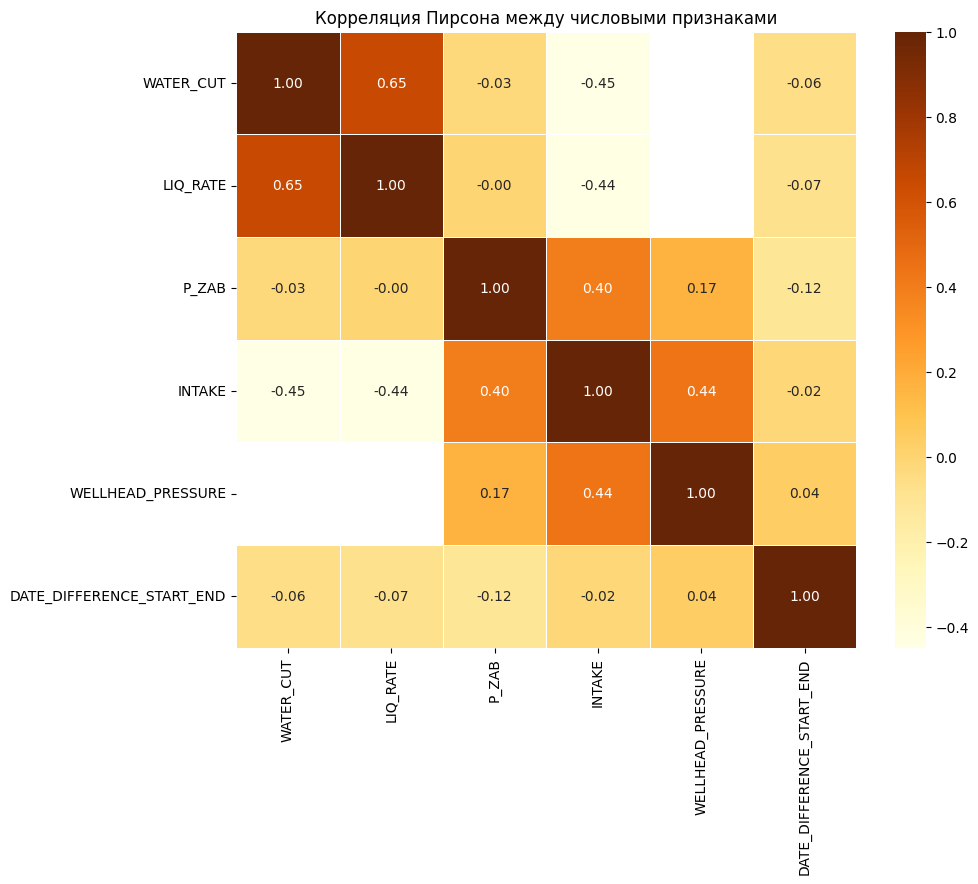

In [47]:
# Корреляция Пирсона для числовых признаков
pearson_corr = df_encoded[['WATER_CUT', 'LIQ_RATE', 'P_ZAB', 'INTAKE', 'WELLHEAD_PRESSURE', 'DATE_DIFFERENCE_START_END']].corr(method='pearson')

# Построим heatmap для корреляции Пирсона
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='YlOrBr', fmt='.2f', linewidths=0.5)
plt.title('Корреляция Пирсона между числовыми признаками')
plt.show()

In [51]:
#Определяем параметр, влияющий на забор скважины
model_1 = smf.ols('INTAKE ~  WATER_CUT + WELLHEAD_PRESSURE + LIQ_RATE + P_ZAB + DATE_DIFFERENCE_START_END + GEOTECH_ACTION + CHARWORK', data=df_encoded).fit()
model_1.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-135.1912,7.319,-18.472,0.000,-149.536,-120.847
DATE_DIFFERENCE_START_END[T.1],5.097e-12,3.72e-13,13.718,0.000,4.37e-12,5.83e-12
DATE_DIFFERENCE_START_END[T.2],-161.3232,6.712,-24.034,0.000,-174.479,-148.167
DATE_DIFFERENCE_START_END[T.3],-42.4138,3.395,-12.492,0.000,-49.069,-35.759
DATE_DIFFERENCE_START_END[T.4],2.4932,2.819,0.884,0.376,-3.032,8.018
DATE_DIFFERENCE_START_END[T.5],-28.5561,3.087,-9.250,0.000,-34.607,-22.505
DATE_DIFFERENCE_START_END[T.6],-8.9259,2.997,-2.978,0.003,-14.800,-3.051
DATE_DIFFERENCE_START_END[T.7],88.9658,3.680,24.178,0.000,81.754,96.178
DATE_DIFFERENCE_START_END[T.8],-61.2218,3.397,-18.023,0.000,-67.880,-54.564
DATE_DIFFERENCE_START_END[T.9],24.7209,7.227,3.421,0.001,10.557,38.885


In [57]:
#Определяем параметры, влияющие на P_ZAB
model_2 = smf.ols('P_ZAB ~  WATER_CUT + WELLHEAD_PRESSURE + LIQ_RATE + INTAKE + DATE_DIFFERENCE_START_END + GEOTECH_ACTION + CHARWORK', data=df_encoded).fit()
model_2.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,31.8176,1.479,21.517,0.000,28.919,34.716
DATE_DIFFERENCE_START_END[T.1],-6.91e-12,1.09e-13,-63.407,0.000,-7.12e-12,-6.7e-12
DATE_DIFFERENCE_START_END[T.2],112.8634,1.311,86.087,0.000,110.294,115.433
DATE_DIFFERENCE_START_END[T.3],18.3067,0.684,26.747,0.000,16.965,19.648
DATE_DIFFERENCE_START_END[T.4],18.8456,0.567,33.259,0.000,17.735,19.956
DATE_DIFFERENCE_START_END[T.5],2.5412,0.624,4.070,0.000,1.317,3.765
DATE_DIFFERENCE_START_END[T.6],-3.1005,0.606,-5.117,0.000,-4.288,-1.913
DATE_DIFFERENCE_START_END[T.7],-7.6638,0.746,-10.276,0.000,-9.126,-6.202
DATE_DIFFERENCE_START_END[T.8],1.5045,0.688,2.187,0.029,0.156,2.853
DATE_DIFFERENCE_START_END[T.9],-46.9097,1.453,-32.280,0.000,-49.758,-44.061


Применение метода причинно-следственного вывода LinGAM

In [52]:
df_encoded.head()

,WELL_NAME,CHARWORK,GEOTECH_ACTION,WATER_CUT,LIQ_RATE,P_ZAB,INTAKE,WELLHEAD_PRESSURE,MEASURED_IN_DATE,DATE_DIFFERENCE_START_END,IS_WORKING
0,127,1,2,20.0,550.0,113.80,0.0,NaN,2018-09-15,3,0
1,127,1,2,20.0,550.0,113.80,0.0,NaN,2018-09-16,3,0
2,127,1,2,20.0,536.0,107.10,0.0,NaN,2018-09-17,3,0
3,127,1,2,10.0,539.0,106.58,0.0,NaN,2018-09-18,3,0
4,127,1,2,10.0,539.0,103.17,0.0,NaN,2018-09-19,3,0


In [85]:
#Находим CI с привязкой к скважинам
X1 = df_encoded.drop(columns = ['MEASURED_IN_DATE', 'IS_WORKING'])
X1.fillna(0, inplace = True)
print(X1.shape)
X1.head(10)

(311156, 9)


,WELL_NAME,CHARWORK,GEOTECH_ACTION,WATER_CUT,LIQ_RATE,P_ZAB,INTAKE,WELLHEAD_PRESSURE,DATE_DIFFERENCE_START_END
0,127,1,2,20.0,550.0,113.80,0.0,0.0,3
1,127,1,2,20.0,550.0,113.80,0.0,0.0,3
2,127,1,2,20.0,536.0,107.10,0.0,0.0,3
3,127,1,2,10.0,539.0,106.58,0.0,0.0,3
4,127,1,2,10.0,539.0,103.17,0.0,0.0,3
5,127,1,2,10.0,514.0,103.17,0.0,0.0,3
6,127,1,2,10.0,502.0,93.25,0.0,0.0,3
7,127,1,2,10.0,502.0,93.25,0.0,0.0,3
8,127,1,2,9.0,485.0,93.20,0.0,0.0,3
9,127,1,2,8.0,485.0,93.15,0.0,0.0,3


Causal order of variables: ['WELL_NAME', 'DATE_DIFFERENCE_START_END', 'WELLHEAD_PRESSURE', 'CHARWORK', 'GEOTECH_ACTION', 'WATER_CUT', 'INTAKE', 'LIQ_RATE', 'P_ZAB']

Adjacency Matrix:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 4.83352671e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -7.10940468e-03
   5.18653648e-04]
 [-6.63898646e-04 -1.94550982e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  2.70004263e-03
   4.93492487e-02]
 [-3.39760282e-03  3.32193335e+01 -5.06985919e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -2.69429854e-01]
 [ 3.34372889e-01  1.31015774e+02 -7.37049642e+00  4.53717767e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -1.56971074e+00]
 [ 5.60600495e-03 -2.48047069e+01 -1.88682029e+00  1.99449320

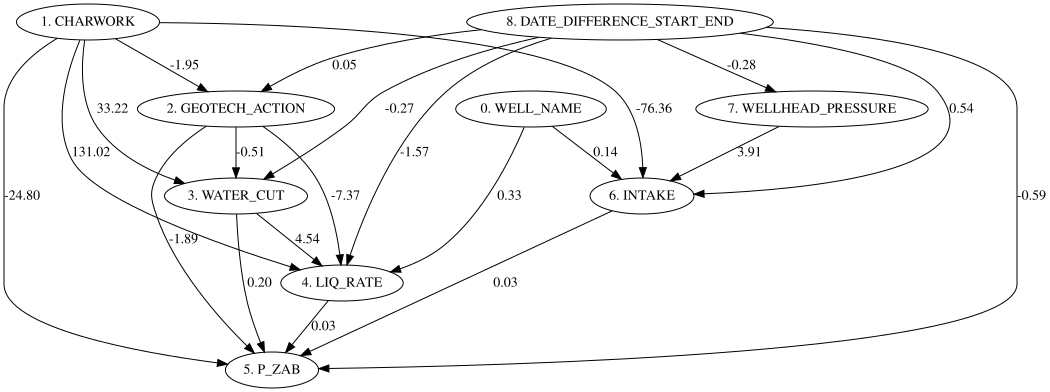

In [86]:
# Строим модель LiNGAM
model = lingam.DirectLiNGAM(measure='pwling')
model.fit(X1)
# Получение порядка переменных (порядка причинности)
order = model.causal_order_
print(f"Causal order of variables: {X1.columns[order].to_list()}")

# Получение матрицы смежности
adjacency_matrix = model.adjacency_matrix_
print("\nAdjacency Matrix:")
print(adjacency_matrix)
labels = [f'{i}. {col}' for i, col in enumerate(X1.columns)]
make_dot(model.adjacency_matrix_, labels)

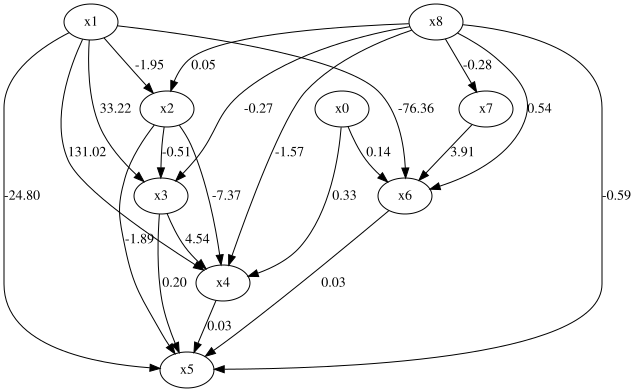

In [87]:
make_dot(adjacency_matrix)

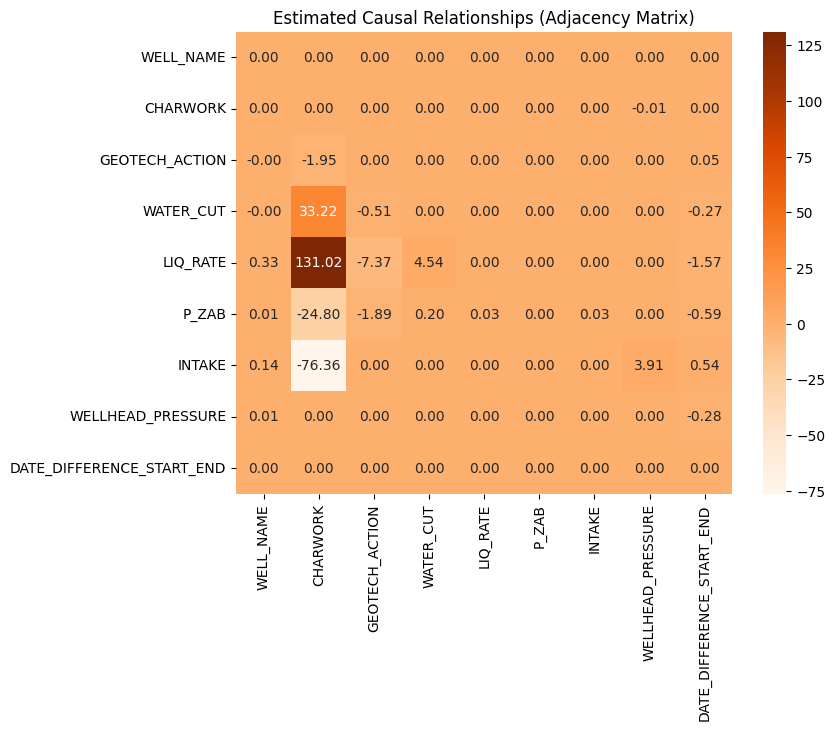

In [88]:
#Визуализируем в виде матрицы
adjacency_df = pd.DataFrame(adjacency_matrix, index=X1.columns, columns=X1.columns)

plt.figure(figsize=(8, 6))
sns.heatmap(adjacency_df, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Estimated Causal Relationships (Adjacency Matrix)")
plt.show()

#ПРОЗНОЗИРОВАНИЕ ВРЕМЕННОГО РЯДА


In [89]:
#Находим CI без привязки к скважинам
X2 = df_encoded.drop(columns = ['WELL_NAME','MEASURED_IN_DATE', 'IS_WORKING'])
X2.fillna(0, inplace = True)
print(X2.shape)
X2.head(10)

(311156, 8)


,CHARWORK,GEOTECH_ACTION,WATER_CUT,LIQ_RATE,P_ZAB,INTAKE,WELLHEAD_PRESSURE,DATE_DIFFERENCE_START_END
0,1,2,20.0,550.0,113.80,0.0,0.0,3
1,1,2,20.0,550.0,113.80,0.0,0.0,3
2,1,2,20.0,536.0,107.10,0.0,0.0,3
3,1,2,10.0,539.0,106.58,0.0,0.0,3
4,1,2,10.0,539.0,103.17,0.0,0.0,3
5,1,2,10.0,514.0,103.17,0.0,0.0,3
6,1,2,10.0,502.0,93.25,0.0,0.0,3
7,1,2,10.0,502.0,93.25,0.0,0.0,3
8,1,2,9.0,485.0,93.20,0.0,0.0,3
9,1,2,8.0,485.0,93.15,0.0,0.0,3


Causal order of variables: ['DATE_DIFFERENCE_START_END', 'WELLHEAD_PRESSURE', 'CHARWORK', 'GEOTECH_ACTION', 'WATER_CUT', 'INTAKE', 'LIQ_RATE', 'P_ZAB']

Adjacency Matrix:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -7.10896358e-03  5.30606081e-04]
 [-1.95241229e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  2.64491449e-03  4.91887411e-02]
 [ 3.32287486e+01 -5.02820159e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -2.70466337e-01]
 [ 1.30433163e+02 -7.78567203e+00  4.52682612e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.47050569e+00]
 [-2.47738739e+01 -1.89185260e+00  1.98009078e-01  2.89682389e-02
   0.00000000e+00  3.08620490e-02  0.00000000e+00 -5.88707904e-01]
 [-7.49388536e+01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  3.92374707e+00  5.75646561e-01]
 [ 0.00000000e+00  0.00000000e+

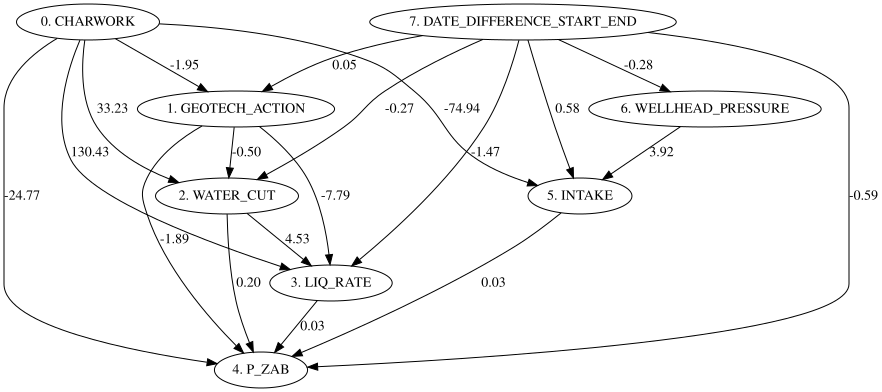

In [90]:
# Строим модель LiNGAM
model = lingam.DirectLiNGAM(measure='pwling')
model.fit(X2)
# Получение порядка переменных (порядка причинности)
order = model.causal_order_
print(f"Causal order of variables: {X2.columns[order].to_list()}")

# Получение матрицы смежности
adjacency_matrix = model.adjacency_matrix_
print("\nAdjacency Matrix:")
print(adjacency_matrix)
labels = [f'{i}. {col}' for i, col in enumerate(X2.columns)]
make_dot(model.adjacency_matrix_, labels)

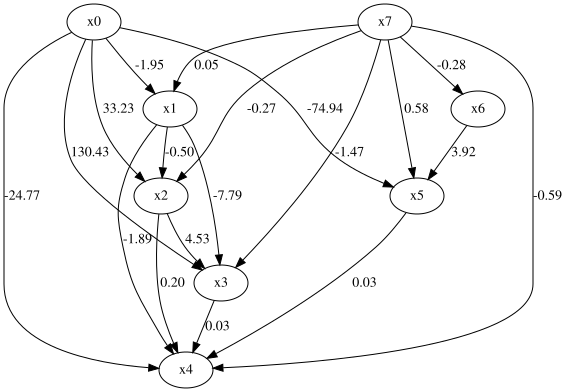

In [91]:
make_dot(adjacency_matrix)

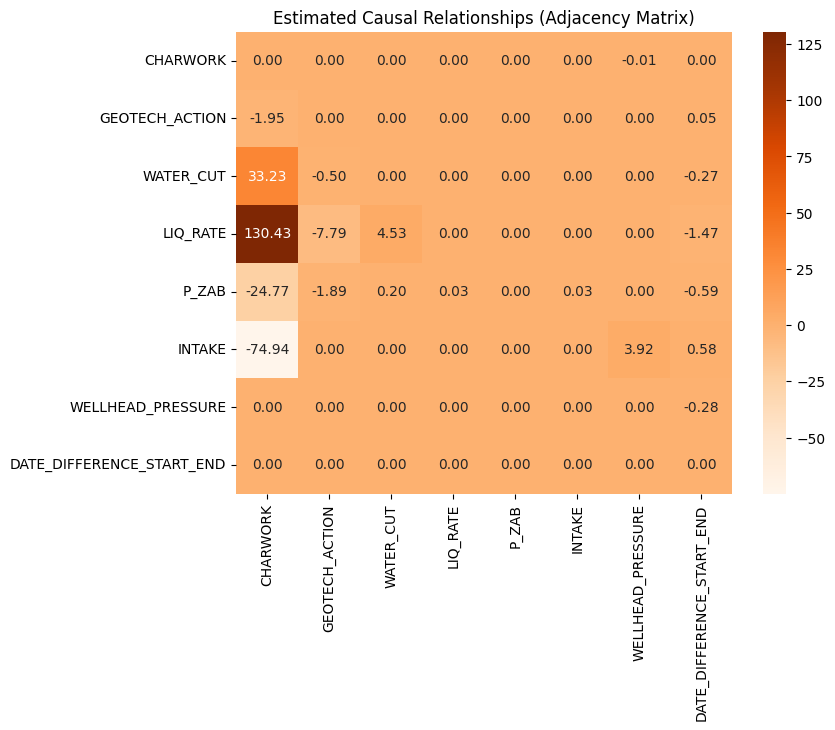

In [92]:
#Визуализируем в виде матрицы
adjacency_df = pd.DataFrame(adjacency_matrix, index=X2.columns, columns=X2.columns)

plt.figure(figsize=(8, 6))
sns.heatmap(adjacency_df, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Estimated Causal Relationships (Adjacency Matrix)")
plt.show()